## Analysis of Portugal's roundabouts

Following the publication of an article on discovercars.com about roundabouts, and to settle an old question about which Portuguese city has the most roundabouts, I decided to write this Python analysis and collect every roundabout in the country, to answer the following questions:

- How many roundabouts are there in Portugal? And how does that compare with Público's article?
- Which municipality has the most roundabouts (absolute number)?
- Which municipality has the most roundabouts per inhabitant?
- Which municipality has the most roundabouts per km²?

The data processing lives in `roundabout.py`, so this notebook and the command-line script produce the same numbers.

In [1]:
import json
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd

from roundabout import (
    assign_municipalities,
    build_overpass_query,
    fetch_roundabout_ways,
    load_boundaries,
    load_municipalities,
    match_city_codes,
    merge_roundabout_ways,
    municipality_stats,
)

### Settings

The municipality boundaries come from the official **CAOP** (*Carta Administrativa Oficial de Portugal*), published by the [Direção-Geral do Território](https://www.dgterritorio.gov.pt/cartografia/cartografia-tematica/caop). CAOP ships the mainland, Madeira and the Azores as separate layers (or files), so list every one you need below. If you don't know the layer names, the next cell lists them.

In [2]:
# Boundary layers as (path, layer) pairs; layer=None reads a file's default layer
# CAOP 2024.1 files from dgterritorio.gov.pt, unzipped into caop/
# (the 2025 edition only changed parishes: every municipality boundary is identical)
BOUNDARY_SOURCES = [
    ("caop/Continente_CAOP2024_1.gpkg", "cont_municipios"),
    ("caop/ArqMadeira_CAOP2024_1.gpkg", "ram_municipios"),
    ("caop/ArqAcores_GOcidental_CAOP2024_1.gpkg", "raa_oci_municipios"),
    ("caop/ArqAcores_GCentral_GOriental_CAOP2024_1.gpkg", "raa_cen_ori_municipios"),
]
NAME_COLUMN = "municipio"  # column holding the municipality name in the CAOP layers
ID_COLUMN = "dtmn"  # unique municipality code, keeps the two Lagoa apart

# Raw Overpass answer, saved so the notebook can be re-run without querying the server again
OSM_CACHE = Path("osm_roundabout_ways.json")

# Municipalities below this population are left out of the per-inhabitant ranking
MIN_POPULATION = 10_000

In [3]:
for path in dict.fromkeys(path for path, _ in BOUNDARY_SOURCES):
    print(path)
    print(gpd.list_layers(path).to_string(index=False), end="\n\n")

caop/Continente_CAOP2024_1.gpkg
                      name geometry_type
cont_areas_administrativas       Polygon
            cont_distritos  MultiPolygon
           cont_freguesias  MultiPolygon
           cont_municipios  MultiPolygon
                cont_nuts1  MultiPolygon
                cont_nuts2  MultiPolygon
                cont_nuts3  MultiPolygon
               cont_trocos    LineString
              layer_styles           NaN
           inf_fonte_troco           NaN

caop/ArqMadeira_CAOP2024_1.gpkg
                     name geometry_type
ram_areas_administrativas       Polygon
            ram_distritos  MultiPolygon
           ram_freguesias  MultiPolygon
           ram_municipios  MultiPolygon
                ram_nuts1  MultiPolygon
                ram_nuts2  MultiPolygon
                ram_nuts3  MultiPolygon
               ram_trocos    LineString
          inf_fonte_troco           NaN
             layer_styles           NaN

caop/ArqAcores_GOcidental_CAOP2024_1.gpkg
 

### Getting the data
To get the roundabouts we query OpenStreetMap through its **Overpass** API, which needs no API key. The query asks for every road (*way*) tagged `junction=roundabout` or `junction=circular` inside Portugal, identified by its ISO code so that no other area named "Portugal" is picked up. `out geom` returns the coordinates of every node of each way, which we'll need below.

In [4]:
print(build_overpass_query())


    [out:json][timeout:600];
    area["ISO3166-1"="PT"][admin_level=2]->.pt;
    way["junction"~"^(roundabout|circular)$"]["highway"]["highway"!~"^(proposed|construction|abandoned|disused|razed|cycleway|footway|path|pedestrian)$"](area.pt);
    out geom;
    


In [5]:
if OSM_CACHE.exists():
    elements = json.loads(OSM_CACHE.read_text())
else:
    elements = fetch_roundabout_ways()  # may take a few minutes
    OSM_CACHE.write_text(json.dumps(elements))

print(f"{len(elements)} roundabout ways downloaded from OpenStreetMap")

27005 roundabout ways downloaded from OpenStreetMap


### One roundabout, several ways
The number above is **not** the number of roundabouts. In OpenStreetMap a roundabout is often split into several ways, one for each segment between an entry and an exit. Plotting the centre of each way around *Rotunda da Boavista* in Porto shows the problem: a single roundabout appears as a cluster of points.

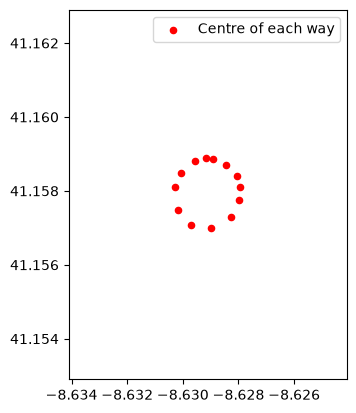

In [6]:
way_centers = pd.DataFrame([
    {
        "osm_way_id": element["id"],
        "latitude": np.mean([point["lat"] for point in element["geometry"]]),
        "longitude": np.mean([point["lon"] for point in element["geometry"]]),
    }
    for element in elements
    if element.get("type") == "way" and element.get("geometry")
])

# Coordinates of Rotunda da Boavista
BOAVISTA = {"lat": 41.1579, "lon": -8.6291, "delta": 0.005}

def zoom_on(ax, lat, lon, delta):
    ax.set_xlim(lon - delta, lon + delta)
    ax.set_ylim(lat - delta, lat + delta)
    ax.set_aspect(1 / np.cos(np.radians(lat)))  # keep distances undistorted

fig, ax = plt.subplots()
ax.scatter(way_centers["longitude"], way_centers["latitude"], s=20, color="red", label="Centre of each way")
zoom_on(ax, **BOAVISTA)
ax.legend()
plt.show()

### Cleaning the data
Ways that belong to the same roundabout are connected: consecutive segments share a node. `merge_roundabout_ways()` groups every set of ways connected through shared nodes and returns one point per roundabout, located at the average of its nodes.

This is more accurate than clustering points by distance (the first version of this notebook used DBSCAN with a 70 m radius): a distance threshold merges two separate roundabouts that are close to each other and can split a very large one, whereas shared nodes only join pieces of the same ring.

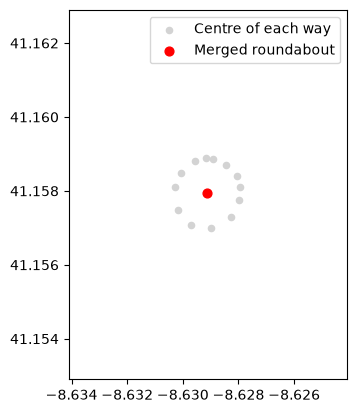

There are 10321 roundabouts in Portugal (27005 OSM ways)


In [7]:
roundabouts = merge_roundabout_ways(elements)

fig, ax = plt.subplots()
ax.scatter(way_centers["longitude"], way_centers["latitude"], s=20, color="lightgrey", label="Centre of each way")
ax.scatter(roundabouts["longitude"], roundabouts["latitude"], s=40, color="red", label="Merged roundabout")
zoom_on(ax, **BOAVISTA)
ax.legend()
plt.show()

print(f"There are {len(roundabouts)} roundabouts in Portugal ({len(way_centers)} OSM ways)")

Note: OpenStreetMap is not an official source. Some junctions that look like roundabouts are mapped as such without being classified as roundabouts by the local authorities, and the reverse also happens.

### Municipality boundaries
We load the CAOP layers and dissolve them into one polygon per municipality (CAOP's finest level is the parish, *freguesia*).

In [8]:
boundaries = load_boundaries(BOUNDARY_SOURCES)
municipality_polygons = boundaries[[ID_COLUMN, NAME_COLUMN, "geometry"]].dissolve(by=[ID_COLUMN, NAME_COLUMN]).reset_index()
print(f"{len(municipality_polygons)} municipalities loaded")

308 municipalities loaded


We can now plot every roundabout on the map of mainland Portugal.

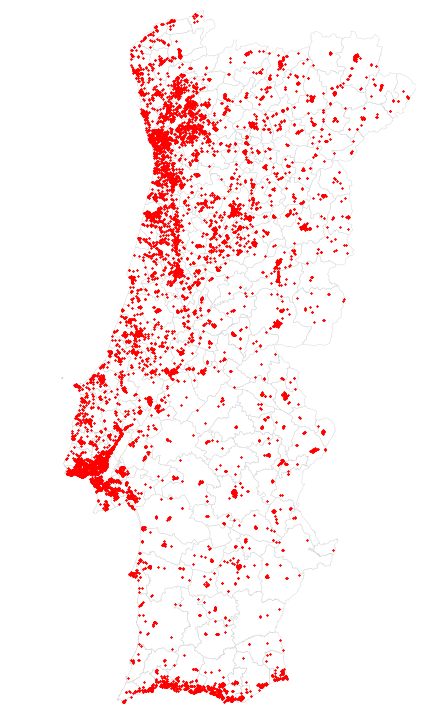

In [9]:
roundabout_points = gpd.GeoDataFrame(
    roundabouts,
    geometry=gpd.points_from_xy(roundabouts["longitude"], roundabouts["latitude"]),
    crs="EPSG:4326",
)

fig, ax = plt.subplots(figsize=(6, 9))
municipality_polygons.plot(ax=ax, color="white", edgecolor="lightgrey", linewidth=0.3)
roundabout_points.plot(ax=ax, markersize=0.5, color="red", marker="x")
ax.set_xlim(-10.0, -6.2)
ax.set_ylim(37, 42.15)
ax.set_axis_off()
plt.show()

### Assigning a municipality to each roundabout
The first version of this notebook reverse-geocoded each roundabout with the Google Maps API. That approach had two problems:

- the requests hit Google's rate limit: about 65% of them failed, so only 21% of the roundabouts were counted in the rankings;
- the `locality` it returned is the town (Ericeira, Porto Salvo…), not the municipality (Mafra, Oeiras…), so those names didn't match the municipality list.

Instead, we check which municipality polygon contains each roundabout. It needs no API key, has no rate limit and gives the same answer on every run.

In [10]:
municipalities = load_municipalities("lista_municípios_pt.csv")

roundabouts = assign_municipalities(roundabouts, municipality_polygons, NAME_COLUMN, ID_COLUMN)
roundabouts = match_city_codes(roundabouts, municipalities)
roundabouts.head()

,roundabout_id,osm_way_ids,latitude,longitude,municipality,city_code
0,0,"[3979160, 1034635570, 1058611428, 1058611429, ...",38.972460,-9.419538,Mafra,MFR
1,1,"[4044459, 1230042017, 1235876203, 1235876213, ...",38.735914,-9.298474,Oeiras,OER
2,2,"[4044461, 1277694937, 1277694938, 1277694981, ...",38.750932,-9.306043,Oeiras,OER
3,3,"[4048425, 1058717149, 1058724299, 1058724300, ...",38.983324,-9.417742,Mafra,MFR
4,4,"[4215045, 1013414761]",38.649237,-9.171587,Almada,ALM


The municipality list comes from [Wikipedia](https://pt.wikipedia.org/wiki/Lista_de_munic%C3%ADpios_de_Portugal) and is joined on its three-letter code rather than on the name, so the two *Lagoa* (Algarve and Azores) and the two *Calheta* (Madeira and Azores) are not mixed up. Any roundabout left without a municipality is listed below: it falls outside the loaded boundaries (a missing CAOP layer, or a point just off the coast) or its CAOP name has no match in the list.

In [11]:
unmatched = roundabouts[roundabouts["city_code"].isna()]
print(f"{len(unmatched)} of {len(roundabouts)} roundabouts without a municipality")
print("Outside every polygon:", unmatched["municipality"].isna().sum())
print("Name not in the list:", sorted(unmatched["municipality"].dropna().unique()))

0 of 10321 roundabouts without a municipality
Outside every polygon: 0
Name not in the list: []


### Results
Municipalities without any roundabout are counted as 0.

In [12]:
stats = municipality_stats(roundabouts, municipalities)
columns = ["city", "population_2021", "area", "roundabouts", "rb_per_km2", "rb_per_10k_inhabitants"]

#### How many roundabouts are there in Portugal?
Fill in the figure reported by Público's article to compare it with ours.

In [13]:
PUBLICO_COUNT = None  # number of roundabouts reported by Público

total = len(roundabouts)
print(f"OpenStreetMap: {total} roundabouts")
if PUBLICO_COUNT:
    print(f"Público: {PUBLICO_COUNT} roundabouts ({total - PUBLICO_COUNT:+d}, {total / PUBLICO_COUNT - 1:+.1%})")

OpenStreetMap: 10321 roundabouts


#### Municipalities with the most roundabouts

In [14]:
stats.sort_values("roundabouts", ascending=False)[columns].head(10)

,city,population_2021,area,roundabouts,rb_per_km2,rb_per_10k_inhabitants
65,Cascais,214134,97.40,230,2.361396,10.740938
256,Sintra,385954,319.23,211,0.660965,5.466973
78,Coimbra,140796,319.40,180,0.563557,12.784454
125,Loulé,72373,763.67,171,0.223919,23.627596
126,Loures,201646,167.24,151,0.902894,7.488371
175,Oeiras,171802,45.88,146,3.182214,8.498155
123,Leiria,128640,108.05,143,1.323461,11.116294
305,Viseu,99693,507.10,143,0.281996,14.344036
16,Almada,177400,70.21,132,1.880074,7.440812
124,Lisboa,544851,100.05,126,1.259370,2.312559


#### Municipalities with the most roundabouts per km²

In [15]:
stats.sort_values("rb_per_km2", ascending=False)[columns].head(10)

,city,population_2021,area,roundabouts,rb_per_km2,rb_per_10k_inhabitants
239,São João da Madeira,22162,7.94,116,14.609572,52.341846
24,Amadora,171719,23.79,106,4.455654,6.172875
175,Oeiras,171802,45.88,146,3.182214,8.498155
87,Entroncamento,20140,13.73,33,2.403496,16.385303
65,Cascais,214134,97.40,230,2.361396,10.740938
174,Odivelas,148156,26.54,59,2.223060,3.982289
16,Almada,177400,70.21,132,1.880074,7.440812
141,Matosinhos,172669,62.42,95,1.521948,5.501856
123,Leiria,128640,108.05,143,1.323461,11.116294
124,Lisboa,544851,100.05,126,1.259370,2.312559


#### Municipalities with the most roundabouts per 10,000 inhabitants
In very small municipalities a single roundabout changes the rate a lot (for example, 4 roundabouts for 2,353 inhabitants is already 17 per 10,000). To keep the ranking meaningful, only municipalities with at least `MIN_POPULATION` inhabitants are ranked here.

In [16]:
populated = stats[stats["population_2021"] >= MIN_POPULATION]
populated.sort_values("rb_per_10k_inhabitants", ascending=False)[columns].head(10)

,city,population_2021,area,roundabouts,rb_per_km2,rb_per_10k_inhabitants
239,São João da Madeira,22162,7.94,116,14.609572,52.341846
167,Murtosa,10488,73.09,43,0.588316,40.999237
172,Óbidos,11940,141.55,42,0.296715,35.175879
111,Grândola,13827,825.94,47,0.056905,33.991466
255,Sines,14214,203.30,47,0.231185,33.065991
169,Nelas,13124,125.71,39,0.310238,29.716550
118,Lagoa (Algarve),23718,88.25,67,0.759207,28.248588
266,Tondela,25939,371.22,66,0.177792,25.444312
5,Albufeira,44158,140.66,112,0.796246,25.363468
136,Mangualde,18294,219.26,44,0.200675,24.051602


#### Roundabout density map

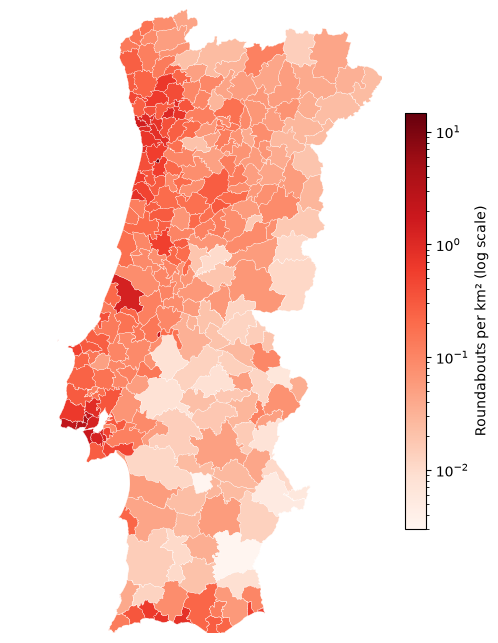

In [17]:
polygon_points = municipality_polygons.representative_point()
density_map = match_city_codes(
    municipality_polygons.assign(latitude=polygon_points.y, longitude=polygon_points.x),
    municipalities,
    name_column=NAME_COLUMN,
).merge(stats[["city_code", "rb_per_km2"]], on="city_code", how="left")

fig, ax = plt.subplots(figsize=(6, 9))
# Log scale: São João da Madeira alone would otherwise wash out the rest of the country
# (municipalities without roundabouts are clipped to the lightest colour)
density = density_map["rb_per_km2"].clip(lower=0.003)
density_map.plot(ax=ax, column=density, cmap="Reds", legend=True, edgecolor="white", linewidth=0.2,
                 norm=LogNorm(vmin=0.003, vmax=density.max()),
                 legend_kwds={"label": "Roundabouts per km² (log scale)", "shrink": 0.6})
ax.set_xlim(-10.0, -6.2)
ax.set_ylim(37, 42.15)
ax.set_axis_off()
plt.show()

### Saving the results

In [18]:
roundabouts.to_csv("Portugal_roundabouts.csv", index=False)
stats.to_csv("pt_cities_rb.csv", index=False)

For a better visualization of this data on a map, you can visit the Tableau dashboard created for it at https://public.tableau.com/app/profile/diogo.freire7485/viz/Portugueseroundabouts/Dashboard1?publish=yes